#### Name:  Jon Stowers

# PHYS 230 Lab Assignment 18

### Monday, April 13, 2026: Chapter 10.2
- Monte Carlo Integration 

In [1]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt
import random 

## The problem: let's use Monte Carlo methods to evaluate the integral below. 
$$ f(x) = -x^3 +6x^2 -x+17 $$
over the range of $ -2 \leq x \leq 5$

## Part 1: "Hit-or-miss" Monte Carlo Method 

#### Step 1: Make a plot of the function to get an idea of what it looks like. 

(**Hint:** After plotting, look at the $y$-axis and determine a reasonable $y_{\text{max}}$ for the axis limit and limit the axis between 0 and this determined value. This will help to define your area for the method.)

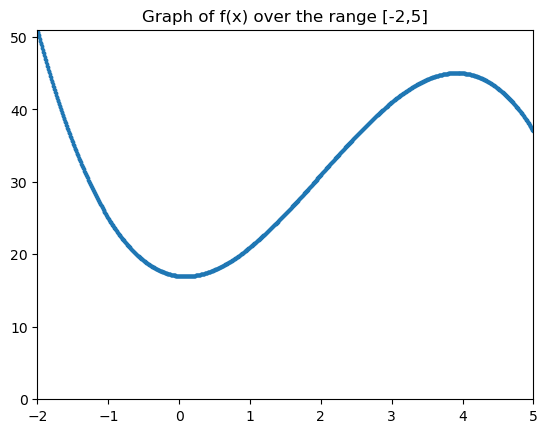

In [6]:

#define function
def f(x):
    return -x**3 + 6*x**2 - x + 17

#limits of integration
x1 = -2
x2 = 5

y1 = 0
y2 = 51 #ymax, determined after plotting for the first time


xpoints = np.linspace(x1,x2,1000)
ypoints = f(xpoints)


plt.scatter(xpoints,ypoints,s=3)
plt.title('Graph of f(x) over the range [-2,5]')
plt.xlim(x1,x2)
plt.ylim(y1,y2)
plt.show()





#### Step 2: Use your graph from step 1 to define the area over which you're evaluating your integral, and apply the "hit-or-miss" method of Monte Carlo integration for 10,000 points. Be sure to run the code a few times to get a sense of the average value returned. 

In [70]:

#limits of bounding rectangle
x1 = -2
x2 = 5
y1 = 0
y2 = 51 

A = (y2-y1)*(x2-x1) #bounding area

N = 10000 #number of points as stipulated

#evaluate integralusing monte carlo method

k = 0 #the count of random points that fall under the curve
for _ in range(N):
    randx = random.uniform(x1,x2) #this is a random float in the range [x1,x2]
    randy = random.uniform(y1,y2) #same as above
    if randy < f(randx): #if our point is under the curve
        k += 1
    
#now calculate the integral using the below formula
I = k*A/N

print('The calculated value of the integral is',I)








The calculated value of the integral is 224.3031


#### Step 3: You can fairly easily solve this integral by hand. Using code, evaluate the true integral below and compare it to your result from step 2.  

In [41]:

def antiderivf(x):
    return -x**4/4 + 2*x**3 - x**2/2 + 17*x


#the value of the integral is the above function at x=5 minus the above function at x=-2

trueintegral = antiderivf(5)-antiderivf(-2)
print('The true value of the integral is',trueintegral)



The true value of the integral is 222.25


Compared to the result from step 2, which hovered around 220, the monte carlo integration is somewhat accurate, but only accurate to about 1%.

#### Step 4: Try evaluating again using both fewer and more points (make sure you show both results). What do you notice about your result? What do you notice about these different results as you run the code multiple times? [To be really complete, try running for a variety of fewer and more points]

In [46]:



#limits of bounding rectangle
x1 = -2
x2 = 5
y1 = 0
y2 = 51 

A = (y2-y1)*(x2-x1) #bounding area

N1 = 10 #fewer points
N2 = 1000000 #more points

#evaluate integralusing monte carlo method

k1 = 0 #the count of random points that fall under the curve
for _ in range(N1):
    randx = random.uniform(x1,x2) #this is a random float in the range [x1,x2]
    randy = random.uniform(y1,y2) #same as above
    if randy < f(randx): #if our point is under the curve
        k1 += 1
    
#now calculate the integral using the below formula
I1 = k1*A/N1



#evaluate integralusing monte carlo method

k2 = 0 #the count of random points that fall under the curve
for _ in range(N2):
    randx = random.uniform(x1,x2) #this is a random float in the range [x1,x2]
    randy = random.uniform(y1,y2) #same as above
    if randy < f(randx): #if our point is under the curve
        k2 += 1
    
#now calculate the integral using the below formula
I2 = k2*A/N2


print('The calculated value of the integral for N =',N1,'points is',I1)
print('The calculated value of the integral for N =',N2,'points is',I2)






The calculated value of the integral for N = 10 points is 214.2
The calculated value of the integral for N = 1000000 points is 222.338172


With more points, the values generated vary less with more points. For 1 million points, the calculated values are close to the true value I calculated in part 3. For N = 10 points, the calculated values swing wildly, but still centered on the same value.

## Part 2: Mean Value Method 

Let's evaluate the same integral using the mean value method instead. 

#### Step 1: Define the function `f(x)` of the integrand

In [48]:

#define function
def f(x):
    return -x**3 + 6*x**2 - x + 17



#### Step 2: Create a a loop with $N=10,000$ points to solve for the integral using the mean value method. 

In [71]:
#limits of integration
x1 = -2
x2 = 5

y1 = 0
y2 = 51 #ymax, determined after plotting for the first time

N = 10000

#we add up, so I starts at 0
I = 0
for _ in range(N):
    randx = random.uniform(x1,x2) #generates a random float in the range 
    I += f(randx)


I *= (x2-x1)/N

print('The calculated value of the integral is',I)




The calculated value of the integral is 222.5484090878643


#### Step 3: In a markdown cell, compare these results with the "hit-or-miss" method from above. What can you conclude about accuracy? speed? To really evaluate this, be sure to run each method with the same number of points multiple times to see the variation in the result. 


With N = 10,000 points, the accuracy and speed of both methods are comparable. When increasing the number of points, the accuracy improves at around the same rate (which matches with our estimations of error for both), but the mean-value method is running markedly faster as the number of points increases (in this case, likely because it only generates half as many random values)


